In [43]:
#Data handling
import pandas as pd
import numpy as np

#visaulization
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr


In [2]:
#Load Dataset
df = pd.read_csv("dirty_cafe_sales.csv")

In [3]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [4]:
#Data Overview
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [48]:
df.describe()

,quantity,price_per_unit,total_spent,transaction_date,total_sales
count,10000.000000,10000.00000,10000.000000,9696,10000.000000
mean,3.027100,2.95265,8.948150,2023-07-01 21:26:17.227723008,8.948150
min,1.000000,1.00000,1.000000,2023-01-01 00:00:00,1.000000
25%,2.000000,2.00000,4.000000,2023-04-01 00:00:00,4.000000
50%,3.000000,3.00000,8.000000,2023-07-02 00:00:00,8.000000
75%,4.000000,4.00000,12.000000,2023-10-02 00:00:00,12.000000
max,5.000000,5.00000,25.000000,2023-12-31 00:00:00,25.000000
std,1.384614,1.24396,5.831191,NaN,5.831191


In [6]:
#columns 

df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [7]:
#Check missing values  before cleaning
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [14]:
# Item → Mode
df['Item'] = df['Item'].fillna(df['Item'].mode()[0])

# Convert to numeric first
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')

# Now fill missing values
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].median())

#total spent
df['Total Spent'] = df['Quantity'] * df['Price Per Unit']

# Payment Method → Mode
df['Payment Method'] = df['Payment Method'].fillna(df['Payment Method'].mode()[0])

# Location → Mode
df['Location'] = df['Location'].fillna(df['Location'].mode()[0])

# Transaction Date → Forward fill
df['Transaction Date'] = df['Transaction Date'].bfill()

In [15]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [16]:
#duplicates
df.duplicated().sum()

np.int64(0)

In [20]:
df.dtypes

Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

In [19]:
#Converted Transaction Date from object to datetime format 
# This allows time-based analysis such as daily or monthly trends

df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

In [27]:
df.columns

Index(['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date', 'total_sales'],
      dtype='object')

In [47]:
#Total Sales is derived by multiplying Quantity and Price Per Unit
# This ensures correct revenue calculation for each transaction
df['total_sales'] = df['quantity'].fillna(0) * df['price_per_unit'].fillna(0)

In [49]:
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,total_sales
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,4.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,12.0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,4.0
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,10.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,4.0


In [26]:
## Standardized column names by converting to lowercase,
# removing spaces, and replacing them with underscores
# This improves consistency and makes coding easier

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

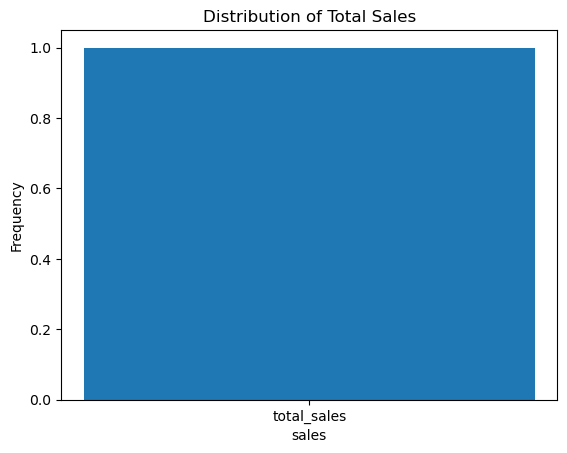

In [50]:
#histogram
plt.hist(['total_sales'], bins='auto')
plt.title("Distribution of Total Sales")
plt.xlabel("sales")
plt.ylabel("Frequency")
plt.show()

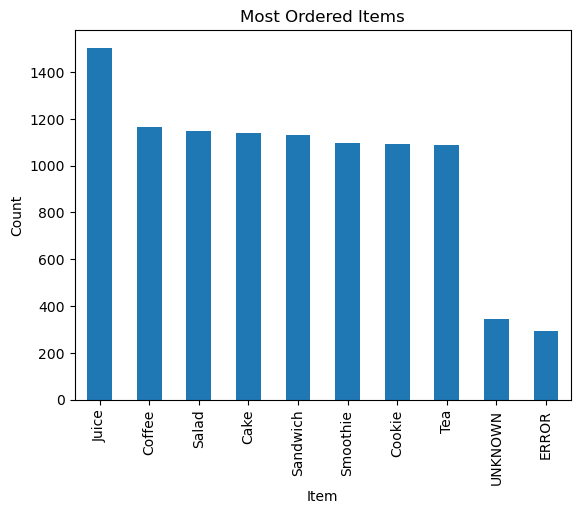

In [32]:
#Bar Chart (Item analysis)
df['item'].value_counts().plot(kind='bar')

plt.title("Most Ordered Items")
plt.xlabel("Item")
plt.ylabel("Count")
plt.show()

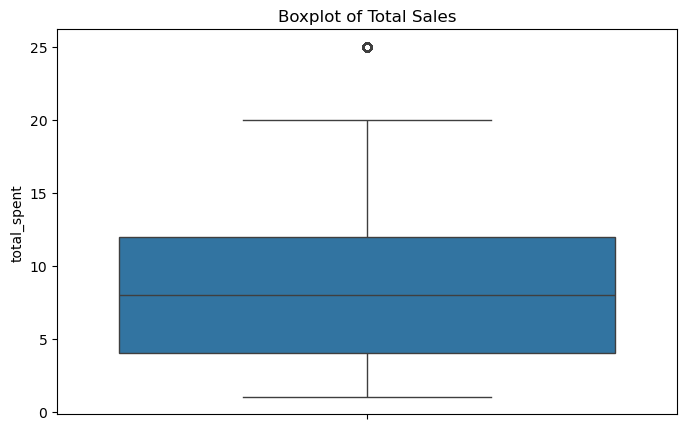

In [36]:
#Outliers chech box plot
plt.figure(figsize=(8,5))

sns.boxplot(y=df['total_spent'])

plt.title("Boxplot of Total Sales")


plt.show()

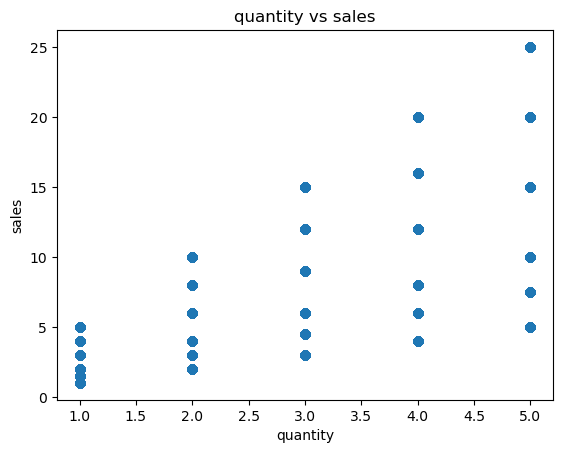

In [38]:
# Scatter plot relationship
plt.scatter(df['quantity'], df['total_sales'])
plt.title("quantity vs sales")
plt.xlabel("quantity")
plt.ylabel("sales")
plt.show()

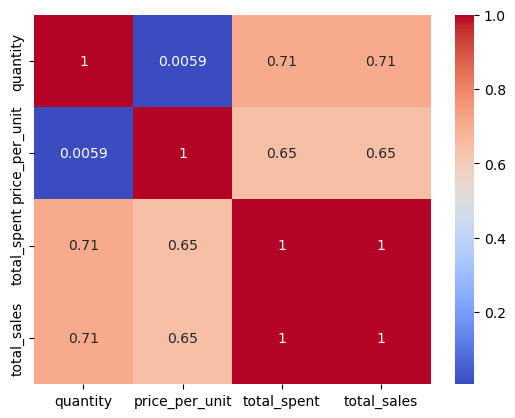

In [39]:
#Correlation(relationship check)
df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [44]:
# Does Quantity affect Sales

corr, p_value = pearsonr(df['quantity'], df['total_sales'])

print(corr, p_value)

if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

0.7075069056590343 0.0
Reject H0


In [ ]:
#Interpertation 
Sales mostly depends on quantity
 Positive correlation exists
 Some outliers in high sales
 Data shows clear purchasing pattern

In [ ]:
#Conclusions 
The analysis shows that Quantity has a strong positive relationship with Total Sales.
Customers buying more items generate higher revenue.
The null hypothesis is rejected.